In [89]:
import pymysql
import os 
from datetime import datetime, timedelta, date

import pandas as pd
# pd.set_option('display.float_format', '{:.2f}'.format)
import numpy as np
import re
import calendar
from decimal import Decimal, ROUND_HALF_UP
import matplotlib.pyplot as plt

<details>
<summary><b>Peak Forecasting Results Import and Reshape Documentation</b></summary>

### Purpose

This block imports the historical peak forecasting workbook and converts the source data from a wide Excel layout into a normalized long-format table.

The source worksheet stores forecast information separately for each utility zone (Eversource, National Grid, BECO, and Vermont). This structure is convenient for reporting but difficult to analyze because equivalent fields are spread across multiple column groups.

### Processing Steps

- Import and clean the source worksheet.
- Remove blank rows and summary records (Total, Overall, YTD).
- Map each utility zone's columns into a common schema.
- Reshape the data from wide format to long format.
- Clean forecast values and standardize missing values.
- Convert date fields to proper date types.

### Output

The resulting dataframe, `Peak_Forecasting_Results_Long`, contains one row per forecasted peak event and includes:

- Forecast month
- Utility zone
- Forecast date
- Hour ending
- Forecasted peak value
- Date confirmed to MMWEC (when available)

This structure is used throughout the forecasting workflow because it supports filtering, aggregation, visualization, and downstream analysis more effectively than the original workbook layout.

</details>

In [66]:
import pandas as pd

path = r"N:\Peak Alert notification files\MMWEC Peak Program Results Including BECO and VT.xlsx"

headers = [
    "Month-Year", "Number of Peaks Called",
    "Eversource Date", "Eversource Hour Ending", "Eversource Forecasted Peak", "Eversource Date Confirmed to MMWEC",
    "National Grid Date", "National Grid Hour Ending", "National Grid Forecasted Peak", "National Grid Date Confirmed to MMWEC",
    "Boston Edison Company Date", "Boston Edison Company Hour Ending", "Boston Edison Company Forecasted Peak",
    "VT Date", "VT Hour Ending", "VT Forecasted Peak",
    "Actual Peak Date", "Actual Peak Hour Ending", "Actual Peak Load", "Actual Forecasted Peak"
]

zone_map = {
    "Eversource": ["Eversource Date", "Eversource Hour Ending", "Eversource Forecasted Peak", "Eversource Date Confirmed to MMWEC"],
    "National Grid": ["National Grid Date", "National Grid Hour Ending", "National Grid Forecasted Peak", "National Grid Date Confirmed to MMWEC"],
    "Boston Edison Company": ["Boston Edison Company Date", "Boston Edison Company Hour Ending", "Boston Edison Company Forecasted Peak"],
    "Vermont": ["VT Date", "VT Hour Ending", "VT Forecasted Peak"]
}

df = (
    pd.read_excel(path, sheet_name="2017-2025 Peak Results", skiprows=7, header=None)
    .iloc[:, 1:]
    .iloc[:, :len(headers)]
)

df.columns = headers

df = (
    df.replace([r"^\s*$", ""], pd.NA, regex=True)
      .dropna(how="all")
)

df = df[
    ~df["Month-Year"].astype(str).str.contains(r"\b(Total|Overall|YTD)\b", case=False, na=False)
].reset_index(drop=True)

Peak_Forecasting_Results_Long = pd.concat(
    [
        (
            df[["Month-Year", "Number of Peaks Called"] + cols]
            .rename(columns={
                cols[0]: "Date",
                cols[1]: "Hour Ending",
                cols[2]: "Forecasted Peak",
                **({cols[3]: "Date Confirmed to MMWEC"} if len(cols) == 4 else {})
            })
            .assign(
                **{
                    "Zone Long": zone,
                    "Zone Short": (
                        "NU" if zone == "Eversource"
                        else "NEP" if zone == "National Grid"
                        else "BECO" if zone == "Boston Edison Company"
                        else "VT"
                    )
                },
                **({"Date Confirmed to MMWEC": pd.NA} if len(cols) == 3 else {})
            )
            [[
                "Month-Year",
                "Number of Peaks Called",
                "Zone Long",
                "Zone Short",
                "Date",
                "Hour Ending",
                "Forecasted Peak",
                "Date Confirmed to MMWEC"
            ]]
        )
        for zone, cols in zone_map.items()
    ],
    ignore_index=True
)

Peak_Forecasting_Results_Long = (
    Peak_Forecasting_Results_Long
    .replace([r"^\s*$", "", "nan", "NaN", "None", "NaT"], pd.NA, regex=True)
    .dropna(subset=["Date", "Hour Ending", "Forecasted Peak"], how="all")
    .reset_index(drop=True)
)

Peak_Forecasting_Results_Long["Forecasted Peak"] = (
    Peak_Forecasting_Results_Long["Forecasted Peak"]
    .astype("string")
    .str.replace("*", "", regex=False)
    .str.replace("#", "", regex=False)
    .str.strip()
    .replace("", pd.NA)
)

for col in ["Month-Year", "Date", "Date Confirmed to MMWEC"]:
    Peak_Forecasting_Results_Long[col] = pd.to_datetime(
        Peak_Forecasting_Results_Long[col],
        errors="coerce"
    ).dt.date

Peak_Forecasting_Results_Long = Peak_Forecasting_Results_Long.replace(
    [r"^\s*$", "", "nan", "NaN", "None", "NaT"],
    pd.NA,
    regex=True
)

Peak_Forecasting_Results_Long

C:\Users\Tilsch\AppData\Local\Temp\ipykernel_61928\145719116.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df["Month-Year"].astype(str).str.contains(r"\b(Total|Overall|YTD)\b", case=False, na=False)
C:\Users\Tilsch\AppData\Local\Temp\ipykernel_61928\145719116.py:98: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Peak_Forecasting_Results_Long = Peak_Forecasting_Results_Long.replace(


,Month-Year,Number of Peaks Called,Zone Long,Zone Short,Date,Hour Ending,Forecasted Peak,Date Confirmed to MMWEC
0,2017-01-01,1.0,Eversource,NU,2017-01-09,19.0,Yes,NaT
1,2017-02-01,3.0,Eversource,NU,2017-02-09,19.0,Yes,NaT
2,2017-03-01,3.0,Eversource,NU,2017-03-15,20.0,Yes,NaT
3,2017-04-01,2.0,Eversource,NU,2017-04-06,18.0,No,NaT
4,2017-05-01,1.0,Eversource,NU,2017-05-18,18.0,Yes,NaT
...,...,...,...,...,...,...,...,...
347,2026-01-01,11.0,Vermont,VT,2026-01-25,16.0,No,NaT
348,2026-02-01,4.0,Vermont,VT,2026-02-08,18.0,<NA>,NaT
349,2026-03-01,2.0,Vermont,VT,2026-03-02,22.0,<NA>,NaT
350,2026-04-01,NaN,Vermont,VT,2026-04-07,22.0,<NA>,NaT


<details>
<summary><b>Meter Data Extraction and Mapping Documentation</b></summary>

### Purpose

This block retrieves hourly meter data from the Rosenware database and converts raw meter IDs into a clean, analysis-ready dataframe.

### Processing Steps

- Connect to the Rosenware database and execute SQL queries.
- Load meter metadata from reference tables (`uploads`, `members`, `units`, and `iso_type`).
- Map meter IDs to readable town, meter, unit, and ISO type information.
- Pull hourly meter values for the selected forecast period.
- Convert kWh values to MWh and adjust charge meters to negative values.
- Aggregate data by date, hour, and town.
- Add time-based fields used throughout the forecasting process.

### Output

The resulting dataframe contains one hourly observation per town and includes:

- Date and time attributes (`date`, `year`, `month`, `day`, `he`)
- Town and meter identifiers
- Meter value (`MWh`)
- Unique hourly record ID

This dataset serves as the primary meter input for downstream RNS forecasting and analysis.

</details>

In [67]:
def database_connector(server = '192.168.1.10',
                       username = 'sa',
                       password = 'sasa', 
                       database = 'rosenware'):
    connection = pymysql.connect(host=server, user=username, password=password, database=database)
    return connection.cursor()

Executecursor = database_connector()

def get_dataframe(query):
    Executecursor.execute(query)
    data = Executecursor.fetchall()
    
    table = query[query.index('`')+1:]
    table = table[:table.index('`')]
    
    Executecursor.execute(f'SHOW COLUMNS FROM `{table}`')
    columns =  [i[0] for i in Executecursor.fetchall()]
    
    df = pd.DataFrame(data, columns = columns)
    return df

# Function for rounding to 2 decimals
def r2(x):
    return Decimal(str(x)).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)



class CreateMeterMapper:
    def __init__ ( self ):
        
        # mapping queries
        self.meter_names = get_dataframe('SELECT * FROM `uploads` ORDER BY id')
        self.member_ids = get_dataframe('SELECT * FROM `members` ORDER BY id').set_index('id').to_dict()['name']
        self.value_denotation = get_dataframe('SELECT * FROM `units` ORDER BY id').set_index('id').to_dict()['name']
        self.iso_type = get_dataframe('SELECT * FROM `iso_type` ORDER BY id').set_index('id').to_dict()['type']
        
        # Mapping Data
        mapper_data = self.main_mapper()
        self.mapping_df = mapper_data[0]
        self.mapping_dict = mapper_data[1]


    def get_available_meters( self , member_search):
        df = get_dataframe(f"SELECT * FROM `uploads` WHERE units_id = 1 ORDER BY id;")
        df['mlp'] = df['member_id'].map(self.member_ids)
        all_meter_names = df.groupby(['mlp'])[['name']].agg(list).to_dict()['name']
        print(sorted(list(all_meter_names.keys())))

        if member_search is not None:
            display(sorted(all_meter_names[member_search]))
        else:
            display(all_meter_names)

        
    def main_mapper( self ):
        meter_name_df = self.meter_names
        
        meter_name_df['mlp'] = meter_name_df['member_id'].map(self.member_ids)
        meter_name_df['unit'] = meter_name_df['units_id'].map(self.value_denotation)
        meter_name_df['iso_type'] = meter_name_df['iso_type_id'].map(self.iso_type)
        
        meter_name_df = meter_name_df[['id', 'mlp','name','unit','iso_type']]
        
        return meter_name_df, meter_name_df.set_index('id').to_dict('index')


    def get_meter_id_list(self, meter_dict):
        mapper_df = self.mapping_df
        dct = {}

        for mlp in meter_dict:
            meter_id_lst = mapper_df.loc[(mapper_df['mlp'] == mlp) & (mapper_df['name'].isin(meter_dict[mlp]))]['id'].to_list()
            dct[mlp] = meter_id_lst

        return f"({', '.join(map(str, [item for sublist in dct.values() for item in sublist]))})"
     
    def meter_dataframe( self , meter_dict):
        meter_query = self.get_meter_id_list(meter_dict)
        mapper = self.mapping_dict
        
        date = str(pd.to_datetime('today').date())
        meter_df = get_dataframe(f"SELECT * FROM `upload_calculations` WHERE upload IN {meter_query} AND `date` >= '{forecast_meter_start_date}' AND `date` <= '{forecast_meter_end_date}' ORDER BY date ASC, hour ASC, upload ASC;")
        meter_df['town'] = meter_df['upload'].map(lambda x: mapper[x]['mlp'])
        meter_df['name'] = meter_df['upload'].map(lambda x: mapper[x]['name'])
        meter_df['unit'] = meter_df['upload'].map(lambda x: mapper[x]['unit'])
        meter_df['iso_type'] = meter_df['upload'].map(lambda x: mapper[x]['iso_type'])
        
        # Convert to MWh
        meter_df['value'] = meter_df['value'] / 1000 # convert to MW
        meter_df['unit'] = meter_df['unit'].str.replace('kWh','MWh')


        rename_mapper = {
            'Groton': 'Groton Load',
            'Ipswich': 'Ipswich Tie',
            'South Hadley': 'South Hadley Load',
            'Wakefield': 'Wakefield Load',
            'Ashburnham': 'Ashburnham Load',
            'Paxton': 'Paxton Load',
            'West Boylston': 'West Boylston Load',
        }

        meter_df['value'] = np.where(meter_df['name'].str.contains('Charge'), meter_df['value']*-1,meter_df['value'])
        meter_df['value'] = meter_df['value'].apply(r2)
        
        meter_df = meter_df.groupby(['date', 'hour', 'town'])[['value']].sum().reset_index()
        meter_df['name'] = meter_df['town'].map(rename_mapper)  
        # Time framework
        meter_df['date'] = pd.to_datetime(meter_df['date'])
        meter_df['year'] = meter_df['date'].dt.year
        meter_df['month'] = meter_df['date'].dt.month
        meter_df['day'] = meter_df['date'].dt.day
        meter_df['id'] = meter_df['date'].dt.date.astype(str) + '_' + meter_df['hour'].astype(str)

        
        return meter_df.rename(columns = {'hour':'he'})[['date','year','month','day','he','town','name','value','id']]

    
def FetchMeterData(load_meters = None):
    data = CreateMeterMapper().meter_dataframe(load_meters)

    return data

def DisplayMeters(member_search = None): return CreateMeterMapper().get_available_meters(member_search)
    

<details>
<summary><b>RNS Schedule Preparation Documentation</b></summary>

### Purpose

This block creates the annual RNS schedule used throughout the forecasting model and expands it into a monthly structure for downstream calculations.

### Processing Steps

- Define annual RNS values by year.
- Display the current RNS value and visualize historical/projected RNS trends.
- Calculate the average monthly RNS by dividing the annual value by 12.
- Expand each annual record into 12 monthly records.
- Create a month field to support joins with monthly forecasting and load datasets.

### Output

The resulting dataframe contains one record per year-month combination with:

- `Year`
- `Month`
- `RNS`
- `Average Monthly RNS`

This structure allows annual RNS values to be incorporated into monthly forecasting and cost calculations.

</details>

Current_RNS: 220.0


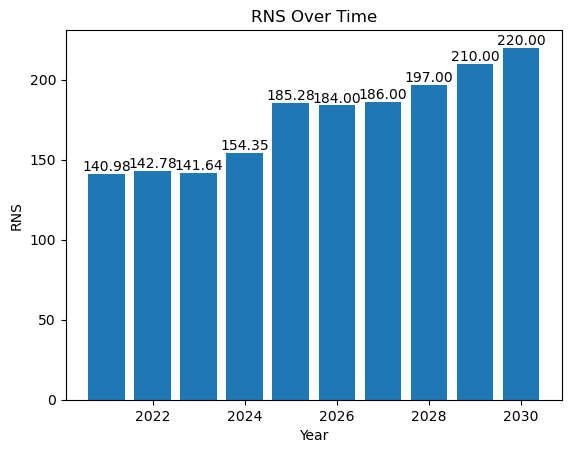

In [68]:
# Link to RNS Rates
# https://mmwecorg-my.sharepoint.com/:x:/g/personal/jbourgoin_mmwec_org/IQAy6luAIu8WQJ4Nc5Q5E954Abqef7tkv4ajPBlrRKMtfdQ?wdExp=TEAMS-TREATMENT&web=1&CID=2ff7a87d-6a5c-4fcd-950e-f58d756301ea&isSPOFile=1&ovuser=c2ac5d88-97de-4aba-9040-8edad9a7ed7a%2CJTilsch%40mmwec.org&clickparams=eyJBcHBOYW1lIjoiVGVhbXMtRGVza3RvcCIsIkFwcFZlcnNpb24iOiI0OS8yNjA0MTYxNzIxNSIsIkhhc0ZlZGVyYXRlZFVzZXIiOmZhbHNlfQ%3D%3D

RNS_Schedule = pd.DataFrame({
    "Year":[2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030],
    "RNS":[140.9813, 142.77923, 141.64499, 154.3539024, 185.2771301, 184, 186, 197, 210, 220]
})

Current_RNS = RNS_Schedule["RNS"].iloc[-1]
print(f"Current_RNS: {round(Current_RNS,2)}")

bars = plt.bar(RNS_Schedule["Year"], RNS_Schedule["RNS"])
plt.title("RNS Over Time")
plt.xlabel("Year")
plt.ylabel("RNS")
plt.bar_label(bars, fmt='%.2f')
plt.show()

RNS_Schedule["Average Monthly RNS"] = (RNS_Schedule["RNS"] / 12).round(4)
RNS_Schedule = RNS_Schedule.loc[RNS_Schedule.index.repeat(12)].reset_index(drop=True)
RNS_Schedule["Month"] = list(range(1,13)) * (len(RNS_Schedule) // 12)

In [69]:
# Town_IDs = pd.read_excel(r"C:\Users\Tilsch\OneDrive - mmwec.org\Desktop\Projects\Town IDs.xlsx")
# Town_IDs

<summary><b>Display the RNS Schedule</b></summary>

In [70]:
RNS_Schedule 

,Year,RNS,Average Monthly RNS,Month
0,2021,140.9813,11.7484,1
1,2021,140.9813,11.7484,2
2,2021,140.9813,11.7484,3
3,2021,140.9813,11.7484,4
4,2021,140.9813,11.7484,5
...,...,...,...,...
115,2030,220.0000,18.3333,8
116,2030,220.0000,18.3333,9
117,2030,220.0000,18.3333,10
118,2030,220.0000,18.3333,11


<summary><b>ISO PID Look-Up Table</b></summary>

In [71]:
# Definition dict
ISO_PID = {
    'Ashburnham'                         : '1',
    'Boylston'                           : '4',
    'Braintree'                          : '5',
    'Chicopee'                           : '7',
    'CMEEC'                              : '8',
    'Danvers'                            : '9',
    'Georgetown'                         : '39',
    'Groton'                             : '40',
    'Hingham'                            : '42',
    'Holden'                             : '43',
    'Holyoke'                            : '44',
    'Hudson'                             : '45',
    'Hull'                               : '72',
    'Ipswich'                            : '73',
    'Littleton'                          : '75',
    'Mansfield'                          : '77',
    'Marblehead'                         : '78',
    'Middleborough'                      : '79',
    'Middleton'                          : '80',
    'Belmont'                            : '89',
    'Concord'                            : '90',
    'North Attleborough'                 : '111',
    'Pascoag Utility District (RI)'      : '116',
    'Paxton'                             : '117',
    'Peabody'                            : '144',
    'Princeton'                          : '145',
    'Rowley'                             : '146',
    'Reading'                            : '148',
    'Shrewsbury'                         : '149',
    'South Hadley'                       : '150',
    'Merrimac'                           : '151',
    'Sterling'                           : '152',
    'Taunton'                            : '153',
    'Norwood'                            : '158',
    'Templeton'                          : '180',
    'Wakefield'                          : '183',
    'West Boylston'                      : '186',
    'Westfield'                          : '187',
    'Chester'                            : '51300',
    'Green Mountain Power Corp.'         : '50275',
    'Groveland'                          : '50276',
    'Stowe'                              : '50324',
    'Wellesley'                          : '50484',
    'Russell'                            : '51306',
    'Block Island Municipal'             : '133042',
    'Ludlow'                             : '50289001',
    'Hardwick'                           : '50289002',
    'Morrisville'                        : '50289003',
    'Swanton'                            : '50289004',
    'Lyndonville'                        : '50289005',
    'MMWEC'                              : '76'
}
ISO_PID_DF = pd.DataFrame([ISO_PID]).T.reset_index()
ISO_PID_DF.columns = ["MLP", "PID"]

ISO_PID_DF
# reversed_dict_iso_id = {value: key for key, value in iso_id.items()}

,MLP,PID
0,Ashburnham,1
1,Boylston,4
2,Braintree,5
3,Chicopee,7
4,CMEEC,8
5,Danvers,9
6,Georgetown,39
7,Groton,40
8,Hingham,42
9,Holden,43


<summary><b>Transmission Zone Look-Up Table</b></summary>

In [72]:
# Definition dict
zone_mapper = {
    'Ashburnham'    : ['NEP',  'National Grid'],
    'Boylston'      : ['NEP',  'National Grid'],
    'Belmont'       : ['BECO', 'Boston Edison Company'],
    'Chester'       : ['NU',   'Eversource'],
    'Chicopee'      : ['NU',   'Eversource'],
    'Groton'        : ['NEP',  'National Grid'],
    'Holyoke'       : ['NU',   'Eversource'],
    'Hull'          : ['BECO', 'Boston Edison Company'],
    'Ipswich'       : ['NEP',  'National Grid'],
    'Mansfield'     : ['NEP',  'National Grid'],
    'Marblehead'    : ['NEP',  'National Grid'],
    'Peabody'       : ['NEP',  'National Grid'],
    'Paxton'        : ['NEP',  'National Grid'],
    'Princeton'     : ['NEP',  'National Grid'],
    'Russell'       : ['NU',   'Eversource'],
    'South Hadley'  : ['NU',   'Eversource'],
    'Shrewsbury'    : ['NEP',  'National Grid'],
    'Sterling'      : ['NEP',  'National Grid'],
    'Templeton'     : ['NEP',  'National Grid'],
    'Wakefield'     : ['NEP',  'National Grid'],
    'West Boylston' : ['NEP',  'National Grid']
}

Zone_DF = (
    pd.DataFrame.from_dict(
        zone_mapper,
        orient="index",
        columns=["Transmission Zone Short", "Transmission Zone Long"]
    )
    .reset_index()
    .rename(columns={"index": "MLP"})
)

Zone_DF

,MLP,Transmission Zone Short,Transmission Zone Long
0,Ashburnham,NEP,National Grid
1,Boylston,NEP,National Grid
2,Belmont,BECO,Boston Edison Company
3,Chester,NU,Eversource
4,Chicopee,NU,Eversource
5,Groton,NEP,National Grid
6,Holyoke,NU,Eversource
7,Hull,BECO,Boston Edison Company
8,Ipswich,NEP,National Grid
9,Mansfield,NEP,National Grid


<details>
<summary><b>Meter Selection and Forecast Period Documentation</b></summary>

### Purpose

This block defines the MLP meters included in the RNS forecast, pulls the last three years of hourly meter data, and attaches transmission zone and ISO PID metadata.

### Processing Steps

- Define the load, tie-line, and battery meters needed for each MLP.
- Set the forecast meter pull window from today back three years.
- Retrieve hourly meter data using `FetchMeterData()`.
- Standardize column names.
- Join transmission zone information from `Zone_DF`.
- Join ISO participant ID information from `ISO_PID_DF`.
- Rebuild date fields used for filtering, grouping, and downstream calculations.

### Output

The resulting `meter_data` dataframe contains cleaned hourly meter records with:

- Date and hour fields
- Town / MLP
- Meter value
- Transmission zone
- ISO PID
- Year, month, and day fields

This dataset is the main hourly load input used for RNS forecasting and monthly aggregation.

</details>

In [73]:
meters = {
    'Ashburnham': ['Ashburnham Load'],
    'Boylston': ['Boylston Load'],
    'Chester' : ['Chester Load'],
    'Chicopee': ['Chicopee Tie'],
    'Groton': ['Groton Load', 'Battery 1 Charge', 'Battery 1 Discharge', 'Battery 2 Charge', 'Battery 2 Discharge'],
    'Holyoke': ['HGE Load'],
    'Hull': ['Hull Load TIE LINE'],
    'Ipswich': ['Ipswich Tie'],
    'Mansfield': ['Mansfield Load'],
    'Marblehead': ['Marblehead TIE LINE'],
    'Paxton': ['Paxton Load', 'Battery Charge', 'Battery Discharge'],
    'Peabody': ['Peabody TIE LINE'],
    'Princeton': ['Princeton TIE LINE'],
    'Russell': ['Russell Load'],
    'Shrewsbury': ['Shrewsbury TIE LINE'],
    'South Hadley': ['South Hadley Load'],
    'Sterling': ['Sterling TIE LINE'],
    'Templeton': ['Templeton TIE LINE'],
    'Wakefield': ['Wakefield Load', 'Battery Charge', 'Battery Discharge'],
    'West Boylston': ['West Boylston Load', 'Battery Charge', 'Battery Discharge']
}

forecast_meter_end_date = date.today()
forecast_meter_start_date = (
    pd.to_datetime(forecast_meter_end_date) - pd.Timedelta(days=365 * 3)
).strftime('%Y-%m-%d')

meter_data = FetchMeterData(meters)
meter_data.columns = meter_data.columns.str.strip().str.title()

meter_data = meter_data.merge(
    Zone_DF[["MLP", "Transmission Zone Short", "Transmission Zone Long"]],
    left_on="Town",
    right_on="MLP",
    how="left"
).drop(columns="MLP")

meter_data = meter_data.merge(
    ISO_PID_DF[["MLP", "PID"]],
    left_on="Town",
    right_on="MLP",
    how="left"
).drop(columns="MLP")

meter_data["Date"] = pd.to_datetime(meter_data["Date"])
meter_data["Year"] = meter_data["Date"].dt.year
meter_data["Month"] = meter_data["Date"].dt.month
meter_data["Day"] = meter_data["Date"].dt.day

meter_data

,Date,Year,Month,Day,He,Town,Name,Value,Id,Transmission Zone Short,Transmission Zone Long,PID
0,2023-06-09,2023,6,9,1,Ashburnham,Ashburnham Load,2.61,2023-06-09_1,NEP,National Grid,1
1,2023-06-09,2023,6,9,1,Boylston,NaN,3.12,2023-06-09_1,NEP,National Grid,4
2,2023-06-09,2023,6,9,1,Chester,NaN,0.42,2023-06-09_1,NU,Eversource,51300
3,2023-06-09,2023,6,9,1,Chicopee,NaN,34.29,2023-06-09_1,NU,Eversource,7
4,2023-06-09,2023,6,9,1,Groton,Groton Load,6.03,2023-06-09_1,NEP,National Grid,40
...,...,...,...,...,...,...,...,...,...,...,...,...
525655,2026-06-07,2026,6,7,24,South Hadley,South Hadley Load,10.74,2026-06-07_24,NU,Eversource,150
525656,2026-06-07,2026,6,7,24,Sterling,NaN,6.99,2026-06-07_24,NEP,National Grid,152
525657,2026-06-07,2026,6,7,24,Templeton,NaN,6.91,2026-06-07_24,NEP,National Grid,180
525658,2026-06-07,2026,6,7,24,Wakefield,Wakefield Load,15.65,2026-06-07_24,NEP,National Grid,183


<details>
<summary><b>Monthly Town Peak Table Documentation</b></summary>

### Purpose

This block builds the main town-month forecasting table by combining monthly town records, forecasted peak dates/hours, RNS rates, and actual coincidental peak loads.

### Processing Steps

- Define the forecast year range.
- Extract year and month from the peak forecasting results.
- Create a lookup table from hourly meter data.
- Build a complete town/year/month grid from 2024 through 2030.
- Attach transmission zone metadata for each town.
- Join forecasted coincidental peak date and hour by transmission zone, year, and month.
- Add the peak day and assign a year-rank weighting field for historical years.
- Join monthly RNS values from `RNS_Schedule`.
- Pull the actual town load at the coincidental peak date and hour.

### Output

The resulting `Monthly_Town_Table` contains one row per town, year, and month with:

- Transmission zone
- Coincidental peak date and hour
- RNS and average monthly RNS
- Coincidental peak load
- Year rank for weighting historical observations

This table is the core monthly structure used to calculate weighted coincidental peak load and RNS cost exposure by town.

</details>

In [74]:
from datetime import date

start_year, end_year = 2024, 2030
current_year = date.today().year

Peak_Forecasting_Results_Long["Date"] = pd.to_datetime(Peak_Forecasting_Results_Long["Date"], errors="coerce")
Peak_Forecasting_Results_Long["Year"] = Peak_Forecasting_Results_Long["Date"].dt.year
Peak_Forecasting_Results_Long["Month"] = Peak_Forecasting_Results_Long["Date"].dt.month

meter_lookup = meter_data[["Town", "Year", "Month", "Day", "He", "Value"]].copy()

year_rank_map = {
    year: rank
    for rank, year in enumerate(range(start_year, min(end_year, current_year) + 1), start=1)
}

Monthly_Town_Table = (
    pd.MultiIndex.from_product(
        [sorted(meter_data["Town"].dropna().unique()), range(start_year, end_year + 1), range(1, 13)],
        names=["Town", "Year", "Month"]
    )
    .to_frame(index=False)
    .merge(Zone_DF[["MLP", "Transmission Zone Short", "Transmission Zone Long"]], left_on="Town", right_on="MLP", how="left")
    .drop(columns="MLP")
    .merge(Peak_Forecasting_Results_Long[["Zone Short", "Year", "Month", "Date", "Hour Ending"]],
           left_on=["Transmission Zone Short", "Year", "Month"],
           right_on=["Zone Short", "Year", "Month"],
           how="left")
    .drop(columns="Zone Short")
    .rename(columns={"Date": "Coincidental Peak Date", "Hour Ending": "Coincidental Peak Hour Ending"})
    .assign(
        Day=lambda x: pd.to_datetime(x["Coincidental Peak Date"], errors="coerce").dt.day,
        **{"Year Rank": lambda x: x["Year"].map(year_rank_map)}
    )
    .merge(RNS_Schedule[["Year", "Month", "RNS", "Average Monthly RNS"]], on=["Year", "Month"], how="left")
    .merge(meter_lookup,
           left_on=["Town", "Year", "Month", "Day", "Coincidental Peak Hour Ending"],
           right_on=["Town", "Year", "Month", "Day", "He"],
           how="left")
    .drop(columns="He")
    .rename(columns={"Value": "Coincidental Peak Load"})
)

Monthly_Town_Table

,Town,Year,Month,Transmission Zone Short,Transmission Zone Long,Coincidental Peak Date,Coincidental Peak Hour Ending,Day,Year Rank,RNS,Average Monthly RNS,Coincidental Peak Load
0,Ashburnham,2024,1,NEP,National Grid,2024-01-17,19.0,17.0,1.0,154.353902,12.8628,4.54
1,Ashburnham,2024,2,NEP,National Grid,2024-02-14,19.0,14.0,1.0,154.353902,12.8628,3.43
2,Ashburnham,2024,3,NEP,National Grid,2024-03-11,20.0,11.0,1.0,154.353902,12.8628,2.45
3,Ashburnham,2024,4,NEP,National Grid,2024-04-04,11.0,4.0,1.0,154.353902,12.8628,5.10
4,Ashburnham,2024,5,NEP,National Grid,2024-05-22,19.0,22.0,1.0,154.353902,12.8628,3.07
...,...,...,...,...,...,...,...,...,...,...,...,...
1676,West Boylston,2030,8,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN
1677,West Boylston,2030,9,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN
1678,West Boylston,2030,10,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN
1679,West Boylston,2030,11,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN


<details>
<summary><b>RBACL and RNS Cost Calculation Documentation</b></summary>

### Purpose

This block calculates each town's monthly RBACL using weighted historical coincidental peak loads, then applies the monthly RNS rate to estimate RNS cost exposure.

### Formula

$$
WeightedLoad_i = CoincidentalPeakLoad_i \times YearRank_i
$$

$$
RBACL =
\frac{\sum_i WeightedLoad_i}
{\sum_i YearRank_i}
$$

$$
RNSCost = RBACL \times AverageMonthlyRNS
$$

### Processing Steps

- Validate calculation fields.
- Calculate weighted coincidental peak load for valid historical records.
- Aggregate weighted load and rank totals by town and month.
- Calculate RBACL.
- Merge RBACL back into `Monthly_Town_Table`.
- Calculate monthly RNS cost.

### Output

Adds or updates:

- `Weighted Coincidental Peak Load`
- `RBACL`
- `RNS Cost`

</details>

In [82]:
# Ensure calculation fields are numeric.
Monthly_Town_Table["Coincidental Peak Load"] = pd.to_numeric(Monthly_Town_Table["Coincidental Peak Load"], errors="coerce")
Monthly_Town_Table["Year Rank"] = pd.to_numeric(Monthly_Town_Table["Year Rank"], errors="coerce")
Monthly_Town_Table["Average Monthly RNS"] = pd.to_numeric(Monthly_Town_Table["Average Monthly RNS"], errors="coerce")

# Keep only rows with valid historical load data and positive year-rank weights.
calc_mask = (
    Monthly_Town_Table["Coincidental Peak Load"].notna()
    & Monthly_Town_Table["Year Rank"].notna()
    & (Monthly_Town_Table["Year Rank"] > 0)
)

# Calculate weighted coincidental peak load.
Monthly_Town_Table["Weighted Coincidental Peak Load"] = pd.to_numeric(
    (
        Monthly_Town_Table["Coincidental Peak Load"]
        * Monthly_Town_Table["Year Rank"]
    ).where(calc_mask).round(4),
    errors="coerce"
)

# Calculate RBACL by town and month.
RBACL_Table = (
    Monthly_Town_Table.loc[calc_mask]
    .groupby(["Town", "Month"], as_index=False)
    .agg(
        Weighted_Load_Sum=("Weighted Coincidental Peak Load", "sum"),
        Rank_Sum=("Year Rank", "sum")
    )
)

RBACL_Table["RBACL"] = (
    RBACL_Table["Weighted_Load_Sum"]
    / RBACL_Table["Rank_Sum"]
).round(4)

# Merge RBACL and PID back onto the monthly town table and create final calculated fields.
current_year = pd.Timestamp.today().year
current_month = pd.Timestamp.today().month

Monthly_Town_Table = (
    Monthly_Town_Table
    .drop(columns=["RBACL", "PID", "MLP", "Flag Actual/Forecast", "RNS Cost"], errors="ignore")
    .merge(RBACL_Table[["Town", "Month", "RBACL"]], on=["Town", "Month"], how="left")
    .merge(ISO_PID_DF[["MLP", "PID"]], left_on="Town", right_on="MLP", how="left")
    .drop(columns="MLP")
    .assign(
        **{
            "RNS Cost": lambda x: (x["RBACL"] * x["Average Monthly RNS"]).round(4),

            # Actual = any completed prior month in the current year, or any prior year.
            # Forecast = current month and future months/years.
            "Flag Actual/Forecast": lambda x: np.where(
                (x["Year"] < current_year)
                | ((x["Year"] == current_year) & (x["Month"] < current_month)),
                "Actual",
                "Forecast"
            )
        }
    )
)

Monthly_Town_Table

,Town,Year,Month,Transmission Zone Short,Transmission Zone Long,Coincidental Peak Date,Coincidental Peak Hour Ending,Day,Year Rank,RNS,Average Monthly RNS,Coincidental Peak Load,Weighted Coincidental Peak Load,RBACL,PID,RNS Cost,Flag Actual/Forecast
0,Ashburnham,2024,1,NEP,National Grid,2024-01-17,19.0,17.0,1.0,154.353902,12.8628,4.54,4.54,6.1983,1,79.7275,Actual
1,Ashburnham,2024,2,NEP,National Grid,2024-02-14,19.0,14.0,1.0,154.353902,12.8628,3.43,3.43,4.9983,1,64.2921,Actual
2,Ashburnham,2024,3,NEP,National Grid,2024-03-11,20.0,11.0,1.0,154.353902,12.8628,2.45,2.45,3.6967,1,47.5499,Actual
3,Ashburnham,2024,4,NEP,National Grid,2024-04-04,11.0,4.0,1.0,154.353902,12.8628,5.10,5.10,4.1650,1,53.5736,Actual
4,Ashburnham,2024,5,NEP,National Grid,2024-05-22,19.0,22.0,1.0,154.353902,12.8628,3.07,3.07,2.9967,1,38.5460,Actual
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1676,West Boylston,2030,8,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN,NaN,9.7167,186,178.1392,Forecast
1677,West Boylston,2030,9,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN,NaN,8.5267,186,156.3225,Forecast
1678,West Boylston,2030,10,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN,NaN,7.7500,186,142.0831,Forecast
1679,West Boylston,2030,11,NEP,National Grid,NaT,NaN,NaN,NaN,220.000000,18.3333,NaN,NaN,8.8300,186,161.8830,Forecast


In [ ]:
RNS_Table = pd.DataFrame(columns=[
    'ISO Participant ID',
    'ISO Asset ID',
    'Year',
    'Month',
    'Flag Actual/Forecast',
    'Capacity Quantity',
    'Capacity Price',
    'Forward Reserve MW Hours',
    'Forward Reserve Price',
    'Cost',
    'LNS',
    'RNS',
    'Fwd Capacity Auction CSO',
    'Fwd Capacity Auction Rate',
    'Self Supply CSO',
    'Annual Reconfig Auction 1 CSO',
    'Annual Reconfig Auction 1 Rate',
    'Annual Reconfig Auction 2 CSO',
    'Annual Reconfig Auction 2 Rate',
    'Annual Reconfig Auction 3 CSO',
    'Annual Reconfig Auction 3 Rate',
    'Monthly CSO',
    'Monthly Rate',
    'Peak Contribution',
    'ICR Multiplier',
    'Pioneer SMD Asset File Code'
])

RNS_Table['Year'] = Monthly_Town_Table['Year']
RNS_Table['Month'] = Monthly_Town_Table['Month']
RNS_Table['RNS'] = Monthly_Town_Table['RNS Cost']
RNS_Table['Monthly Rate'] = Monthly_Town_Table['Average Monthly RNS']
RNS_Table['ISO Participant ID'] = Monthly_Town_Table['PID']
RNS_Table['Flag Actual/Forecast'] = Monthly_Town_Table['Flag Actual/Forecast']
RNS_Table['ISO Asset ID'] = '99999995' #RNS CODE, LNS = '99999996'

RNS_Table

,ISO Participant ID,ISO Asset ID,Year,Month,Flag Actual/Forecast,Capacity Quantity,Capacity Price,Forward Reserve MW Hours,Forward Reserve Price,Cost,...,Annual Reconfig Auction 1 Rate,Annual Reconfig Auction 2 CSO,Annual Reconfig Auction 2 Rate,Annual Reconfig Auction 3 CSO,Annual Reconfig Auction 3 Rate,Monthly CSO,Monthly Rate,Peak Contribution,ICR Multiplier,Pioneer SMD Asset File Code
0,1,99999995,2024,1,Actual,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.8628,NaN,NaN,NaN
1,1,99999995,2024,2,Actual,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.8628,NaN,NaN,NaN
2,1,99999995,2024,3,Actual,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.8628,NaN,NaN,NaN
3,1,99999995,2024,4,Actual,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.8628,NaN,NaN,NaN
4,1,99999995,2024,5,Actual,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.8628,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1676,186,99999995,2030,8,Forecast,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.3333,NaN,NaN,NaN
1677,186,99999995,2030,9,Forecast,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.3333,NaN,NaN,NaN
1678,186,99999995,2030,10,Forecast,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.3333,NaN,NaN,NaN
1679,186,99999995,2030,11,Forecast,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.3333,NaN,NaN,NaN


In [90]:
with pd.ExcelWriter("Formatted_Town_Table.xlsx", engine="openpyxl") as writer:
    Monthly_Town_Table.to_excel(
        writer,
        sheet_name="Monthly Town Table",
        index=False
    )

    RNS_Table.to_excel(
        writer,
        sheet_name="Formatted RNS Forecast",
        index=False
    )

os.startfile("Formatted_Town_Table.xlsx")

In [77]:
# Monthly_Town_Table["Coincidental Peak Load"] = pd.to_numeric(
#     Monthly_Town_Table["Coincidental Peak Load"],
#     errors="coerce"
# )

# Monthly_Town_Table["Year Rank"] = pd.to_numeric(
#     Monthly_Town_Table["Year Rank"],
#     errors="coerce"
# )

# Monthly_Town_Table["Weighted Coincidental Peak Load"] = (
#     Monthly_Town_Table["Coincidental Peak Load"]
#     * Monthly_Town_Table["Year Rank"]
# ).round(4)

# RBACL_Table = (
#     Monthly_Town_Table
#     .dropna(subset=["Coincidental Peak Load", "Year Rank"])
#     .groupby(["Town", "Month"], as_index=False)
#     .agg(
#         Weighted_Load_Sum=("Weighted Coincidental Peak Load", "sum"),
#         Rank_Sum=("Year Rank", "sum")
#     )
# )

# RBACL_Table["RBACL"] = (
#     RBACL_Table["Weighted_Load_Sum"]
#     / RBACL_Table["Rank_Sum"]
# ).round(4)

# Monthly_Town_Table = Monthly_Town_Table.merge(
#     RBACL_Table[["Town", "Month", "RBACL"]],
#     on=["Town", "Month"],
#     how="left"
# )

# Monthly_Town_Table

In [78]:
# Monthly_Town_Table["Coincidental Peak Load"] = pd.to_numeric(Monthly_Town_Table["Coincidental Peak Load"], errors="coerce")
# Monthly_Town_Table["Year Rank"] = pd.to_numeric(Monthly_Town_Table["Year Rank"], errors="coerce")
# Monthly_Town_Table["Average Monthly RNS"] = pd.to_numeric(Monthly_Town_Table["Average Monthly RNS"], errors="coerce")

# calc_mask = (
#     Monthly_Town_Table["Coincidental Peak Load"].notna()
#     & Monthly_Town_Table["Year Rank"].notna()
#     & (Monthly_Town_Table["Year Rank"] > 0)
# )

# Monthly_Town_Table["Weighted Coincidental Peak Load"] = pd.NA
# Monthly_Town_Table.loc[calc_mask, "Weighted Coincidental Peak Load"] = (
#     Monthly_Town_Table.loc[calc_mask, "Coincidental Peak Load"]
#     * Monthly_Town_Table.loc[calc_mask, "Year Rank"]
# ).round(4)

# Monthly_Town_Table["Weighted Coincidental Peak Load"] = pd.to_numeric(
#     Monthly_Town_Table["Weighted Coincidental Peak Load"],
#     errors="coerce"
# )

# RBACL_Table = (
#     Monthly_Town_Table.loc[calc_mask]
#     .groupby(["Town", "Month"], as_index=False)
#     .agg(
#         Weighted_Load_Sum=("Weighted Coincidental Peak Load", "sum"),
#         Rank_Sum=("Year Rank", "sum")
#     )
# )

# RBACL_Table["RBACL"] = (
#     pd.to_numeric(RBACL_Table["Weighted_Load_Sum"], errors="coerce")
#     / pd.to_numeric(RBACL_Table["Rank_Sum"], errors="coerce")
# ).astype(float).round(4)

# Monthly_Town_Table = (
#     Monthly_Town_Table
#     .drop(columns=["RBACL"], errors="ignore")
#     .merge(RBACL_Table[["Town", "Month", "RBACL"]], on=["Town", "Month"], how="left")
# )

# Monthly_Town_Table["RNS Cost"] = (
#     Monthly_Town_Table["RBACL"] * Monthly_Town_Table["Average Monthly RNS"]
# ).round(4)

# Monthly_Town_Table

In [79]:
# Monthly_Town_Table["Coincidental Peak Load"] = pd.to_numeric(Monthly_Town_Table["Coincidental Peak Load"], errors="coerce")
# Monthly_Town_Table["Year Rank"] = pd.to_numeric(Monthly_Town_Table["Year Rank"], errors="coerce")

# calc_mask = (
#     Monthly_Town_Table["Coincidental Peak Load"].notna()
#     & Monthly_Town_Table["Year Rank"].notna()
#     & (Monthly_Town_Table["Year Rank"] > 0)
# )

# Monthly_Town_Table["Weighted Coincidental Peak Load"] = pd.NA

# Monthly_Town_Table.loc[calc_mask, "Weighted Coincidental Peak Load"] = (
#     Monthly_Town_Table.loc[calc_mask, "Coincidental Peak Load"]
#     * Monthly_Town_Table.loc[calc_mask, "Year Rank"]
# ).round(4)

# Monthly_Town_Table["Weighted Coincidental Peak Load"] = pd.to_numeric(
#     Monthly_Town_Table["Weighted Coincidental Peak Load"],
#     errors="coerce"
# )

# RBACL_Table = (
#     Monthly_Town_Table.loc[calc_mask]
#     .groupby(["Town", "Month"], as_index=False)
#     .agg(
#         Weighted_Load_Sum=("Weighted Coincidental Peak Load", "sum"),
#         Rank_Sum=("Year Rank", "sum")
#     )
# )

# RBACL_Table["Weighted_Load_Sum"] = pd.to_numeric(RBACL_Table["Weighted_Load_Sum"], errors="coerce")
# RBACL_Table["Rank_Sum"] = pd.to_numeric(RBACL_Table["Rank_Sum"], errors="coerce")

# RBACL_Table["RBACL"] = (
#     RBACL_Table["Weighted_Load_Sum"] / RBACL_Table["Rank_Sum"]
# ).astype(float).round(4)

# Monthly_Town_Table = Monthly_Town_Table.drop(columns=["RBACL"], errors="ignore").merge(
#     RBACL_Table[["Town", "Month", "RBACL"]],
#     on=["Town", "Month"],
#     how="left"
# )

# Monthly_Town_Table["RBACL"] = Monthly_Town_Table["RBACL"].where(calc_mask)

# Monthly_Town_Table